In [19]:
from dotenv import load_dotenv
load_dotenv()

True

In [20]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [21]:
class subGraphState(TypedDict):
    english_text : str
    nepali_text : str

In [22]:
from langchain_openai import ChatOpenAI

In [23]:
llm = ChatOpenAI(model = 'gpt-4o-mini')

In [24]:
def Translate(state:subGraphState):
    prompt = f"convert this english text {state['english_text']} into the nepali text\n keep it natural and human spoken as same as that of english."
    response = llm.invoke(prompt).content
    return {'nepali_text':response}

In [25]:
subGraphBuilder = StateGraph(state_schema=subGraphState)
subGraphBuilder.add_node('Translate',Translate)

subGraphBuilder.add_edge(START,'Translate')


subGraph = subGraphBuilder.compile()


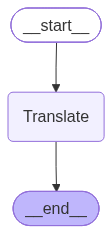

In [26]:
subGraph

In [27]:
subGraph.invoke(input={
    'english_text':'my name is rajendra prasad joshi.'
})

{'english_text': 'my name is rajendra prasad joshi.',
 'nepali_text': 'मेरो नाम राजेन्द्र प्रसाद जोशी हो।'}

### now create a Graph and call the subGraph inside a node


In [28]:
class graphState(TypedDict):
    question : str
    answer : str
    translated_answer : str

In [29]:
def Generate(state:graphState):
    response = llm.invoke(state['question']).content
    return {'answer':response}

In [30]:
def Translate_answer(state:graphState):
    english_text = state['answer']
    response = subGraph.invoke(input ={
        'english_text':english_text
    })
    nepali_text = response['nepali_text']

    return {'translated_answer':nepali_text}

In [32]:
graphBuilder = StateGraph(state_schema=graphState)

graphBuilder.add_node('Generate',Generate)
graphBuilder.add_node('Translate_answer',Translate_answer)

graphBuilder.add_edge(START,'Generate')
graphBuilder.add_edge('Generate','Translate_answer')

graph = graphBuilder.compile()

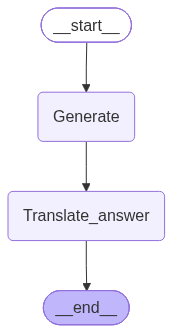

In [33]:
graph

In [34]:
graph.invoke(input={
    'question':'tell me all thing you know about sudurpaschim nepal?'
})

{'question': 'tell me all thing you know about sudurpaschim nepal?',
 'answer': 'Sudurpaschim Province, also known as the Far Western Province, is one of the seven provinces of Nepal, located in the northwestern part of the country. Established after the federal restructuring of Nepal in 2015, it is known for its diverse geography, rich culture, and ethnic diversity. Here are some key aspects of Sudurpaschim Province:\n\n### Geography\n- **Location:** Sudurpaschim Province is bordered by India to the south, and it shares borders with the provinces of Karnali and Gandaki.\n- **Terrain:** The province features a mix of landscapes, including hills, valleys, and plains. The terrain varies from the lowland Terai regions to the Himalayan mountains.\n- **Major Rivers:** The province is home to several rivers, including the Karnali River, which is one of the longest rivers in Nepal.\n\n### Administrative Structure\n- **Capital:** The provincial capital is Dhangadhi, which is an important admin